In [40]:
from gpaw.new.ase_interface import GPAW
from ase import Atoms
import numpy as np
from gpaw import FermiDirac
from ase.visualize import view
import ase

## Primitive cell

In [41]:
primitive = ase.io.read("1MnI2-1.cif")

In [42]:
primitive

Atoms(symbols='MnI2', pbc=True, cell=[[4.165715878531158, 0.0, 0.0], [-2.082857939265579, 3.6076157757561913, 0.0], [0.0, 0.0, 18.02743121316087]], spacegroup_kinds=...)

## Create magnetic supercell

I think the above would not give the same bands.

Note that the supercell is different from the one in the paper.
In the paper they use $Q = (1/3,1/3)$

I think the above corresponds to $Q=(1/3,0)$

IT is the same local 120 degree spin structure. but it is not the same supercell, so the bands might differ.

Trying to create the one they use.

In [43]:
#Define transformation matrix from primitive to magnetic cell
P = np.array([
    [2, 1, 0],
    [-1, 1, 0],
    [0, 0, 1]
])

#defines supercell basis as linear combination of primitive basis
#Unsure if this is defined correctly.

# So Supercell A1 = 2a_1+1a_2
#A2=-a1+a2

Corrected to different supercell above now (initial one didn't converge anyway)

In [44]:
from ase.build import make_supercell

supercell = make_supercell(primitive, P)

## Creating spiral magnetic moments

The magnetization density satisfies:
$$\mathbf{m(r+r_i)} = R_{\hat n}(\mathbf{q\cdot r_i})\mathbf{m(r)}$$
(see the paper).
Take the reference spin $m_0=(0,m,0)$. Then:

$$
\mathbf{m(r+r_i)} = \begin{pmatrix} \cos(\varphi) & -\sin(\varphi)\\ \sin(\varphi) & \cos(\varphi) \end{pmatrix}
\begin{pmatrix} 0 \\ m \end{pmatrix} = \begin{pmatrix} -m\sin(\varphi) \\ m\cos(\varphi) \end{pmatrix}
$$
With $\varphi = \mathbf{q\cdot r_i}$

So, we can calculate the other spins easily based on a reference spin in the y-direction. The spiral does not rotate in the z-direction, thus the 2x2 above.

We could have chosen the reference spin to point in any direction. This physically changes nothing. I chose the y-direction only so the spins align exactly in the way we see them in Fig 1 of the paper.

**Important note about chirality:**

Currently we have a counter-clockwise rotating spiral in the above. If I read the paper Fig 1 d correctly, they have a clockwise rotating spiral. This corresponds to changing $\mathbf{Q} \rightarrow \mathbf{-Q}$.

When there is no SOC (or other symmetry breaking terms), these two options should be identical. SOC breaks the symmetry though, and the chiralities might yield different results.

Below, I include two options. The first is reference spin in x, counterclockwise rotation.

If we wish to Match Fig 1d visually completely, then I found that a reference spin in the y-direction and clock-wise rotating spiral (see -Q in the code) will do the trick.


**Choosing reference spin in the x-direction, counterclockwise rotating spiral**

In [45]:
# m = 4.5
# magmoms = np.zeros((len(supercell), 3))


# A = primitive.cell[:2, :2] #extracts the 2D lattice vectors from the PRIMITIVE CELL. It is a 2x2 matrix.
# A_inv = np.linalg.inv(A.T) #Invert the above, constructs a mapping from cartesian to lattice coordinates. Transposed since ASE stores lattice vectors as rows, we need them as columns.
#                             #This gives \vec{n}=A^{-1}\vec{r}, where r is cartesian position, n is coordinates in lattice basis
# Q = np.array([1/3, 1/3])    #Defines the magnetic ordering vector in reciprocal lattice coordinates.

# for i, atom in enumerate(supercell):
#     if atom.symbol != 'Mn':
#         continue

#     r_cart = atom.position[:2] #extracts the cartesian position of the Mn atom
#     n = A_inv @ r_cart         # Converts to lattice coordinates \vec{r}=n_1a_1+n_2a_2

#     phase = 2 * np.pi * np.dot(Q, n) #each lattice site gets a phase angle depending on its position (given via the lattice coordinates n)

#     magmoms[i] = [                   #Assigns a planar spin spiral
#         m * np.cos(phase),
#         m * np.sin(phase),
#         0.0
#     ]

# supercell.set_initial_magnetic_moments(magmoms)

In [46]:
# view(supercell)
# #In the GUI, go to View->show Magmoms. Also, View->repeat, 2 in x and y

**Choosing reference spin in the y-direction, clockwise rotating spiral**

Matches Fig 1d visually exactly.

In [47]:
m = 4.5
magmoms = np.zeros((len(supercell), 3))


A = primitive.cell[:2, :2] #extracts the 2D lattice vectors from the PRIMITIVE CELL. It is a 2x2 matrix.
A_inv = np.linalg.inv(A.T) #Invert the above, constructs a mapping from cartesian to lattice coordinates. Transposed since ASE stores lattice vectors as rows, we need them as columns.
                            #This gives \vec{n}=A^{-1}\vec{r}, where r is cartesian position, n is coordinates in lattice basis
Q = np.array([1/3, 1/3])    #Defines the magnetic ordering vector in reciprocal lattice coordinates.

for i, atom in enumerate(supercell):
    if atom.symbol != 'Mn':
        continue

    r_cart = atom.position[:2] #extracts the cartesian position of the Mn atom
    n = A_inv @ r_cart         # Converts to lattice coordinates \vec{r}=n_1a_1+n_2a_2

    phase = 2 * np.pi * np.dot(-Q, n) #each lattice site gets a phase angle depending on its position (given via the lattice coordinates n)
    #NOTE minus Q above for clockwise

    magmoms[i] = [                   #Assigns a planar spin spiral, note that m_0=(0,m,0) to get this.
        -m * np.sin(phase),
        m * np.cos(phase),
        0.0
    ]
supercell.set_initial_magnetic_moments(magmoms)

In [48]:
view(supercell)
# #In the GUI, go to View->show Magmoms. Also, View->repeat, 2 in x and y

<Popen: returncode: None args: ['/home/runerce/Desktop/DFT-project-2026/.ven...>

In [49]:
supercell.arrays

{'numbers': array([25, 53, 53, 25, 53, 53, 25, 53, 53]),
 'positions': array([[-2.99569531e-18,  5.17647340e-18,  9.01371561e+00],
        [ 2.08285794e+00,  1.20253859e+00,  1.06632503e+01],
        [-1.76049209e-16,  2.40507718e+00,  7.36418087e+00],
        [-2.08285794e+00,  3.60761578e+00,  9.01371561e+00],
        [-2.23884421e-15,  4.81015437e+00,  1.06632503e+01],
        [ 4.16571588e+00,  2.40507718e+00,  7.36418087e+00],
        [ 2.08285794e+00,  3.60761578e+00,  9.01371561e+00],
        [-2.08285794e+00,  1.20253859e+00,  1.06632503e+01],
        [-4.16571588e+00,  2.40507718e+00,  7.36418087e+00]]),
 'spacegroup_kinds': array([0, 1, 2, 0, 1, 2, 0, 1, 2]),
 'initial_magmoms': array([[ 1.35074009e-17,  4.50000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 3.89711432e+00, -2.25000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]

## GPAW calculator and SCF calc

In [50]:
# --- 4. Setup GPAW Calculator ---
# Article specifies: LDA functional, 600 eV cutoff.
# Symmetry must be off for non-collinear spirals.
# k-points: The magnetic BZ is smaller. If primitive was 12x12x1, supercell needs 4x12x1?
# Let's use a dense grid to resolve the bands smoothly for Fig 1.
calc = GPAW(
    mode={'name':'pw',
          'ecut':300},          # 600 eV cutoff in per paper. Rough first guess
    xc='LDA',              # Paper explicitly uses LDA 
    mixer={'backend': 'pulay',              #This was used to mimic https://gpaw.readthedocs.io/tutorialsexercises/magnetic/spinspiral/spinspiral.html#spin-spiral-calculations
                       'beta': 0.05,
                       'method': 'sum',
                       'nmaxold': 5,
                       'weight': 100},
    kpts={'size':(3,3,1), 'gamma':True},       # Adjusted for the rhombus supercell
    symmetry='off',        # Crucial for spiral
    magmoms=magmoms,       # Enforce non-collinear start
    spinpol=True,          # Needed for non-collinear
    occupations=FermiDirac(0.01),
    txt='MnI2_spiral_supercell_attempt2.txt',
    parallel={'domain': 1, 'band': 1},
    maxiter=50,
)

calc.verbosity=1

supercell.calc = calc

### Run SCF calc

In [51]:
# --- 5. Run Calculation ---
print("Running SCF for magnetic supercell...")
energy = supercell.get_potential_energy()
calc.write('MnI2_spiral_gs_attempt2.gpw')

Running SCF for magnetic supercell...


In [ ]:
#Checking convergence and magnetic moments
energy = supercell.get_potential_energy()
print('energy=',energy) #check for divergence. If it diverges, something wrong in the setup
print('')
#Magmoms
print('Local magnetic moments = ', supercell.get_magnetic_moments())
#We want three Mn moments, roughly 120 degrees apart, magnitude around 3-5 µB
print('')
#Total M
print('Total magnetic moment=', supercell.get_magnetic_moment())
#Should be 0. If they align ferromagnetically, phase may be incorrectly assigned

#Encountering some strangeness. Printing all arrays.
# print('All arrays')
# print(supercell.arrays)

energy= -45.120515386945314

Magnetic moments =  [-3.51683115e-14 -2.00492172e-15 -4.77519257e-16 -1.72875752e-14
 -2.94135332e-15 -7.37155070e-16  3.37052770e-15 -9.50126757e-16
 -2.44447580e-15]

Total magnetic moment= -9.71898772853079e-14


In [53]:
# THIS SHOWS THE LOCAL MAGNETIC MOMENTS AFTER THE CALCULATION
calc.get_non_collinear_magnetic_moments()

array([[-4.25479011e-14,  4.18587088e+00, -3.51683115e-14],
       [ 3.19588186e-07,  1.37942466e-06, -2.00492172e-15],
       [-9.43329949e-15,  8.30960815e-07, -4.77519257e-16],
       [ 3.62511972e+00, -2.09284885e+00, -1.72875752e-14],
       [-8.07085961e-15,  8.30960814e-07, -2.94135332e-15],
       [-3.19588198e-07,  1.37942467e-06, -7.37155070e-16],
       [-3.62511972e+00, -2.09284885e+00,  3.37052770e-15],
       [-3.19588195e-07,  1.37942467e-06, -9.50126757e-16],
       [ 3.19588183e-07,  1.37942466e-06, -2.44447580e-15]])

## Loading the GPW file
Instead of running the SCF code every time

In [54]:
calc2 = GPAW('MnI2_spiral_gs_attempt2.gpw')
atoms = calc2.get_atoms()

In [55]:
# view(atoms)

As seen above, the "Atoms" object isn't updated with the resulting spin structure from the GPAW calculation.

There is an issue with the ASE GUI when there is a calculator attached to the object. The stuff below is just to view the resulting structure after the calculation

In [56]:
atoms2 = calc2.get_atoms()
print('local moments after calc')
print(calc2.get_non_collinear_magnetic_moments()) #Show the calculated local moments)

atoms2.arrays['magmoms'] = calc2.get_non_collinear_magnetic_moments() #Forcing the Atoms magmoms to equal the calculated ones
atoms2.calc = None

local moments after calc
[[-4.25479011e-14  4.18587088e+00 -3.51683115e-14]
 [ 3.19588186e-07  1.37942466e-06 -2.00492172e-15]
 [-9.43329949e-15  8.30960815e-07 -4.77519257e-16]
 [ 3.62511972e+00 -2.09284885e+00 -1.72875752e-14]
 [-8.07085961e-15  8.30960814e-07 -2.94135332e-15]
 [-3.19588198e-07  1.37942467e-06 -7.37155070e-16]
 [-3.62511972e+00 -2.09284885e+00  3.37052770e-15]
 [-3.19588195e-07  1.37942467e-06 -9.50126757e-16]
 [ 3.19588183e-07  1.37942466e-06 -2.44447580e-15]]


In [57]:
# view(atoms2)

The above visually shows that our spin spiral structure is still present

## Bandstructure

We are working in the magnetic supercell, so I guess(?) we will compute bands in the magnetic Brillouin Zone.

In [58]:
from ase.dft.kpoints import bandpath

In [59]:
M = [0.5, 0.0, 0.0]
minus_M = [-0.5, 0.0, 0.0]
Gamma = [0.0, 0.0, 0.0]

kpts = np.array([
    minus_M,
    Gamma,
    M
])

path = bandpath(kpts, supercell.cell, npoints=50)

In [60]:
#Non SCF band calc
calc = GPAW('MnI2_spiral_gs.gpw').fixed_density(
    kpts=path,
    symmetry='off'
)


Diagonalizing LCAO Hamiltonian
Converting LCAO to grid
convergence criteria:
- Maximum integral of absolute [eigenst]ate change: 4e-08 eV^2 / valence electron
maximum number of iterations: 50

     iter     time        total  log10-change:
                         energy   eigst   dens
iter:   1 13:27:50                               +0.0,+0.0,-0.0
iter:   2 13:29:12                -1.81          +0.0,+0.0,-0.0
iter:   3 13:30:35                -2.24          +0.0,+0.0,-0.0
iter:   4 13:31:57                -2.55          +0.0,+0.0,-0.0
iter:   5 13:33:19                -2.80          +0.0,+0.0,-0.0
iter:   6 13:34:42                -3.03          +0.0,+0.0,-0.0
iter:   7 13:36:04                -3.25          +0.0,+0.0,-0.0
iter:   8 13:37:26                -3.45          +0.0,+0.0,-0.0
iter:   9 13:38:49                -3.65          +0.0,+0.0,-0.0
iter:  10 13:40:11                -3.83          +0.0,+0.0,-0.0
iter:  11 13:41:33                -4.01          +0.0,+0.0,-0.0
iter:  1

In [ ]:
ef = calc.get_fermi_level()

# Get eigenvalues for each k-point
e_kn = np.array([calc.get_eigenvalues(kpt=k) for k in range(len(calc.get_ibz_k_points()))])
e_kn -=ef

# Save to a text file
np.savetxt('band_eigvals_MGM_minus_ef.dat', e_kn)

# Get k-points (if you have them in a variable, e.g., 'path')
np.savetxt('band_kpoints_MGM.dat', path)

#Save the location of the high-symmetry points
np.savetxt('highsym_MGM.dat' , kpts)


In [61]:
bs = calc.band_structure()

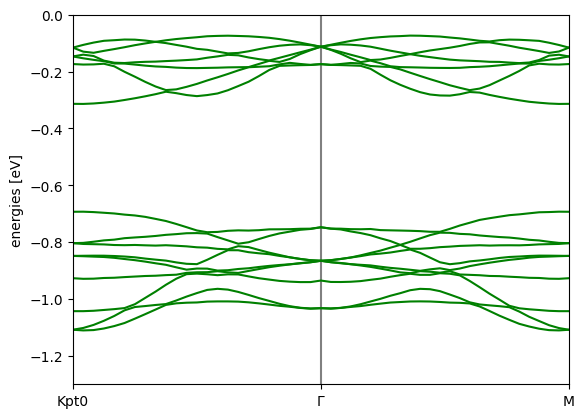

In [ ]:
import matplotlib.pyplot as plt

bs.plot(fermi = calc.get_fermi_level(),emin=-3.3, emax=0)
plt.show()
plt.savefig('bands_no_color.png')   
plt.savefig('bands_no_color.pdf')   

TO script below

In [ ]:
from gpaw.spinorbit import soc_eigenstates

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'

ef = calc.get_fermi_level()

ucvol = np.abs(np.linalg.det(calc.dft.density.nt_sR.desc.cell))
dO_ii = {}
for a, setup in enumerate(calc.dft.setups):
    dO_ii[a] = setup.dO_ii

x = np.loadtxt('band_kpoints_MGM.dat')
X = np.loadtxt('highsym_MGM.dat')
# e_kn = np.array([calc.get_eigenvalues(kpt=k)
                #  for k in range(len(calc.get_ibz_k_points()))])

# e_kn -= ef
#for e_k in e_kn.T:                                                                                                     
#    plt.plot(x, e_k, '--', c='0.5')                                                                                    
e_kn = np.loadtxt('band_eigvals_MGM_minus_ef.dat')


#soc = soc_eigenstates(calc, scale=0)                                                                                   
#e_kn = soc.eigenvalues()                                                                                               
#e_kn -= ef                                                                                                             
s_kn = np.ones_like(e_kn)

for wfs_s in calc.dft.ibzwfs.wfs_qs:
    wfs = wfs_s[0]
    index = wfs.k
    #kpt_v = wfs.kpt_c @ B_cv                                                                                           
    #e_kn[index] = wfs.eig_n * Ha                                                                                       

    print(index)

    psit_nsG = wfs.psit_nX.data[:]
    psit1_nG = psit_nsG[:, 0, :]
    psit2_nG = psit_nsG[:, 1, :]

    s_kn[index] = (np.sum(psit1_nG.conj() * psit1_nG - psit2_nG.conj() * psit2_nG, axis=1) * ucvol).real
    #s_kn[index] = (np.sum(psit1_nG.conj() * psit2_nG + psit2_nG.conj() * psit1_nG, axis=1) * ucvol).real               

    for a, P_nsi in wfs.P_ani.items():
        P1_ni = P_nsi[:, 0, :]
        P2_ni = P_nsi[:, 1, :]

s_kn[index] += np.einsum('ni,nj,ij->n', P1_ni.conj(), P1_ni, dO_ii[a]).real
s_kn[index] -= np.einsum('ni,nj,ij->n', P2_ni.conj(), P2_ni, dO_ii[a]).real
#s_kn[index] += np.einsum('ni,nj,ij->n', P1_ni.conj(), P2_ni, dO_ii[a]).real                                    
#s_kn[index] += np.einsum('ni,nj,ij->n', P2_ni.conj(), P1_ni, dO_ii[a]).real                                    

s_kn[0, 0] = 1
s_kn[0, 1] = -1

np.savetxt('spintexture_MGM.dat', s_kn)


plt.xticks(X, [r'$\mathrm{-\bar M}$', r'$\Gamma$', r'$\mathrm{\bar M}$'], size=16)
plt.yticks([-2, -1, 0, 1], [-2, -1, 0, 1], size=14)
for i in range(len(X))[1:-1]:
    plt.plot(2 * [X[i]], [1.1 * np.min(e_kn), 1.1 * np.max(e_kn)],
             c='0.5', linewidth=0.5)

things = plt.scatter(np.tile(x, len(e_kn.T)),
                     e_kn.T.reshape(-1),
                     c=s_kn.T.reshape(-1),
                     s=2)
plt.colorbar(things)
plt.ylabel(r'$\varepsilon_n(k)\;\mathrm{[eV]}$', size=24)
plt.axhline(y=0, color='0.5', linestyle='-')
plt.axis([0, x[-1], -2.4, 1.4])
plt.tight_layout()
plt.show()
plt.savefig('bands_colored.png')
plt.savefig('bands_colored.pdf')   